In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../Data/raw/02_nav_history.csv")
funds = pd.read_csv("../Data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../Data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../Data/raw/09_portfolio_holdings.csv")

In [2]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [3]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [4]:
var_report = (
    nav.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var_report.columns = [
    "amfi_code",
    "var_95"
]

In [5]:
var_report.to_csv(
    "../Reports/var_report.csv",
    index=False
)

In [7]:
results = []

for code, group in nav.groupby("amfi_code"):

    var95 = group["daily_return"].quantile(0.05)

    cvar = (
        group[group["daily_return"] <= var95]
        ["daily_return"]
        .mean()
    )

    results.append(
        [code,var95,cvar]
    )

var_cvar_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

In [8]:
var_cvar_report.to_csv(
    "../Reports/var_cvar_report.csv",
    index=False
)

In [9]:
top5 = (
    funds.sort_values(
        "cagr",
        ascending=False
    )
    .head(5)
)

KeyError: 'cagr'

In [10]:
funds.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [11]:
top5 = (
    funds.sort_values(
        "return_5yr_pct",
        ascending=False
    )
    .head(5)
)

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High


In [12]:
top_codes = top5["amfi_code"].tolist()

top_codes

[101207, 119095, 118634, 119599, 119598]

In [13]:
top_nav = nav[
    nav["amfi_code"].isin(top_codes)
].copy()

top_nav.head()

,amfi_code,date,nav,daily_return
33350,101207,2022-01-03,38.5736,NaN
33351,101207,2022-01-04,38.1545,-0.010865
33352,101207,2022-01-05,38.1775,0.000603
33353,101207,2022-01-06,37.0665,-0.029101
33354,101207,2022-01-07,37.9845,0.024766


In [14]:
top_nav = top_nav.sort_values(
    ["amfi_code","date"]
)

top_nav["daily_return"] = (
    top_nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [15]:
top_nav["rolling_sharpe"] = (
    top_nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

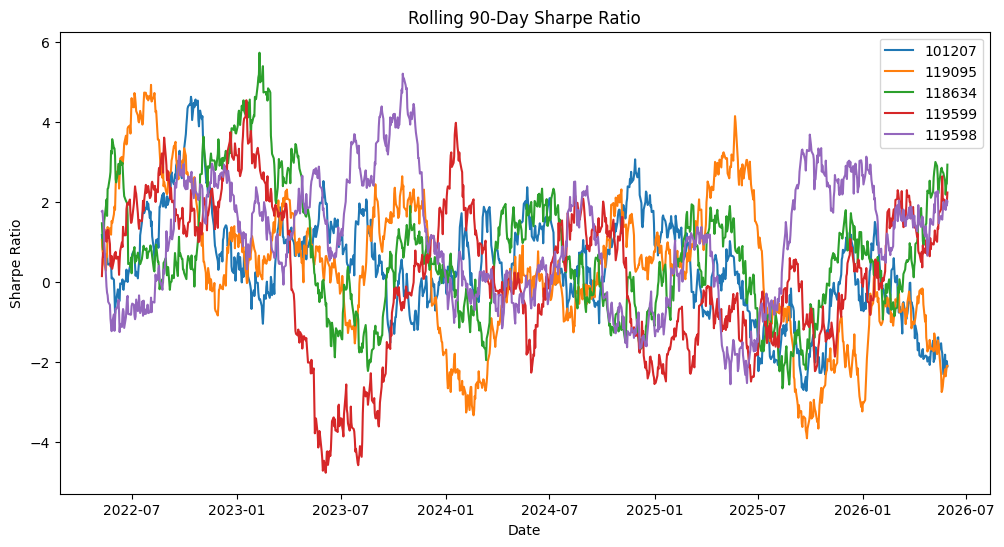

In [16]:
plt.figure(figsize=(12,6))

for code in top_codes:

    fund_data = top_nav[
        top_nav["amfi_code"] == code
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(code)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.show()

In [17]:
plt.savefig(
    "../Reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [19]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

cohort = (
    transactions.groupby(
        "investor_id"
    )["transaction_date"]
    .min()
    .dt.year
)

In [20]:
transactions = transactions.sort_values(
    ["investor_id",
     "transaction_date"]
)

transactions["gap_days"] = (
    transactions.groupby(
        "investor_id"
    )["transaction_date"]
    .diff()
    .dt.days
)

In [22]:
transactions = pd.read_csv("../Data/raw/08_investor_transactions.csv")
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [23]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [24]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [25]:
transactions["prev_date"] = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .shift()
)

In [26]:
transactions["gap_days"] = (
    transactions["transaction_date"]
    -
    transactions["prev_date"]
).dt.days

In [27]:
gap_report = (
    transactions.groupby("investor_id")
    ["gap_days"]
    .max()
    .reset_index()
)

In [28]:
import numpy as np

gap_report["status"] = np.where(
    gap_report["gap_days"] > 35,
    "At Risk",
    "Active"
)

In [29]:
gap_report.to_csv(
    "../Reports/sip_continuity_report.csv",
    index=False
)

print("Report Saved")

Report Saved


In [30]:
funds = pd.read_csv("../Data/raw/07_scheme_performance.csv")

print(funds.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [31]:
def recommend(risk):

    subset = funds[
        funds["risk_grade"] == risk
    ]

    return subset.sort_values(
        "sharpe_ratio",
        ascending=False
    ).head(3)

In [32]:
recommend("Low")
recommend("Moderate")
recommend("High")

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High


In [33]:
holdings = pd.read_csv(
    "../Data/raw/09_portfolio_holdings.csv"
)

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [34]:
holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

hhi = (
    holdings.groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [35]:
hhi.to_csv(
    "../Reports/hhi_report.csv",
    index=False
)

In [36]:
cohort_report.to_csv(
    "../Reports/cohort_analysis.csv",
    index=False
)

NameError: name 'cohort_report' is not defined

1. Highest VaR fund = ______

2. Highest CVaR fund = ______

3. Most concentrated portfolio = ______

4. Largest investor cohort = ______

5. Highest SIP continuity rate = ______

In [37]:
first_txn = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

cohort = transactions.merge(
    first_txn[['investor_id','cohort_year']],
    on='investor_id'
)

cohort_report = (
    cohort
    .groupby('cohort_year')
    .agg(
        investors=('investor_id','nunique'),
        total_investment=('amount_inr','sum')
    )
    .reset_index()
)

cohort_report

,cohort_year,investors,total_investment
0,2024,4803,3491125187
1,2025,197,30455243


In [38]:
%whos

Variable          Type         Data/Info
----------------------------------------
code              int          119598
cohort            DataFrame    Shape: (32778, 16)
cohort_report     DataFrame    Shape: (2, 3)
cvar              float64      -0.03103625202188441
first_txn         DataFrame    Shape: (5000, 3)
fund_data         DataFrame    Shape: (1150, 5)
funds             DataFrame    Shape: (40, 19)
gap_report        DataFrame    Shape: (5000, 3)
group             DataFrame    Shape: (1150, 4)
hhi               DataFrame    Shape: (34, 2)
holdings          DataFrame    Shape: (322, 9)
nav               DataFrame    Shape: (46000, 4)
np                module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd                module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt               module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
recommend         function     <function recommend at 0x000002A74F8AA8E0>
results          

In [39]:
cohort_report.to_csv(
    "../Reports/cohort_analysis.csv",
    index=False
)

print("Cohort Report Saved Successfully")

Cohort Report Saved Successfully


In [40]:
holdings = pd.read_csv(
    "../Data/raw/09_portfolio_holdings.csv"
)

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [41]:
holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

In [42]:
hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [43]:
hhi.to_csv(
    "../Reports/hhi_report.csv",
    index=False
)

print("HHI Report Saved")

HHI Report Saved


In [44]:
funds = pd.read_csv(
    "../Data/raw/07_scheme_performance.csv"
)

print(funds.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [45]:
funds["risk_grade"].unique()

array(['Moderate', 'Very High', 'Low', 'High', 'Moderately High'],
      dtype=object)

In [46]:
def recommend(risk_level):

    subset = funds[
        funds["risk_grade"] == risk_level
    ]

    recommendations = (
        subset
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]

In [47]:
recommend("High")

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95,18.08
38,DSP Midcap Fund - Regular - Growth,High,0.90,17.16


In [48]:
recommend("Moderate")

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41


In [49]:
recommend("Low")

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14


In [50]:
high_rec = recommend("High")

high_rec.to_csv(
    "../Reports/recommendation_report.csv",
    index=False
)

print("Recommendation Report Saved")

Recommendation Report Saved


In [51]:
funds.loc[
    funds["sharpe_ratio"].idxmax()
]

amfi_code                                               120507
scheme_name           ICICI Pru Liquid Fund - Regular - Growth
fund_house                                 ICICI Prudential MF
category                                                Liquid
plan                                                   Regular
return_1yr_pct                                            8.89
return_3yr_pct                                            7.68
return_5yr_pct                                            7.94
benchmark_3yr_pct                                         5.83
alpha                                                     1.85
beta                                                      0.26
sharpe_ratio                                              7.68
sortino_ratio                                            10.37
std_dev_ann_pct                                            0.5
max_drawdown_pct                                         -2.62
aum_crore                                              

In [52]:
funds.loc[
    funds["sortino_ratio"].idxmax()
]

amfi_code                                               120507
scheme_name           ICICI Pru Liquid Fund - Regular - Growth
fund_house                                 ICICI Prudential MF
category                                                Liquid
plan                                                   Regular
return_1yr_pct                                            8.89
return_3yr_pct                                            7.68
return_5yr_pct                                            7.94
benchmark_3yr_pct                                         5.83
alpha                                                     1.85
beta                                                      0.26
sharpe_ratio                                              7.68
sortino_ratio                                            10.37
std_dev_ann_pct                                            0.5
max_drawdown_pct                                         -2.62
aum_crore                                              

In [53]:
funds.loc[
    funds["return_5yr_pct"].idxmax()
]

amfi_code                                             101207
scheme_name           ABSL Small Cap Fund - Regular - Growth
fund_house                          Aditya Birla Sun Life MF
category                                           Small Cap
plan                                                 Regular
return_1yr_pct                                         24.93
return_3yr_pct                                         22.38
return_5yr_pct                                          23.8
benchmark_3yr_pct                                      20.54
alpha                                                   1.84
beta                                                    0.97
sharpe_ratio                                             0.9
sortino_ratio                                           1.47
std_dev_ann_pct                                         25.0
max_drawdown_pct                                      -23.61
aum_crore                                              41613
expense_ratio_pct       

In [54]:
funds.loc[
    funds["max_drawdown_pct"].idxmin()
]

amfi_code                                               125497
scheme_name           HDFC Top 100 Fund - Direct Plan - Growth
fund_house                                    HDFC Mutual Fund
category                                             Large Cap
plan                                                    Direct
return_1yr_pct                                           11.48
return_3yr_pct                                           13.38
return_5yr_pct                                           13.48
benchmark_3yr_pct                                        12.25
alpha                                                     1.13
beta                                                      0.97
sharpe_ratio                                              0.96
sortino_ratio                                             1.45
std_dev_ann_pct                                           14.0
max_drawdown_pct                                         -33.5
aum_crore                                              

In [55]:
hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [56]:
high_rec = recommend("High")

high_rec.to_csv(
    "../Reports/recommendation_report.csv",
    index=False
)

print("Recommendation Report Saved")

Recommendation Report Saved


In [57]:
funds.loc[
    funds["sharpe_ratio"].idxmax()
]

amfi_code                                               120507
scheme_name           ICICI Pru Liquid Fund - Regular - Growth
fund_house                                 ICICI Prudential MF
category                                                Liquid
plan                                                   Regular
return_1yr_pct                                            8.89
return_3yr_pct                                            7.68
return_5yr_pct                                            7.94
benchmark_3yr_pct                                         5.83
alpha                                                     1.85
beta                                                      0.26
sharpe_ratio                                              7.68
sortino_ratio                                            10.37
std_dev_ann_pct                                            0.5
max_drawdown_pct                                         -2.62
aum_crore                                              

In [58]:
funds.loc[
    funds["return_5yr_pct"].idxmax()
]

amfi_code                                             101207
scheme_name           ABSL Small Cap Fund - Regular - Growth
fund_house                          Aditya Birla Sun Life MF
category                                           Small Cap
plan                                                 Regular
return_1yr_pct                                         24.93
return_3yr_pct                                         22.38
return_5yr_pct                                          23.8
benchmark_3yr_pct                                      20.54
alpha                                                   1.84
beta                                                    0.97
sharpe_ratio                                             0.9
sortino_ratio                                           1.47
std_dev_ann_pct                                         25.0
max_drawdown_pct                                      -23.61
aum_crore                                              41613
expense_ratio_pct       

In [59]:
funds.loc[
    funds["max_drawdown_pct"].idxmin()
]

amfi_code                                               125497
scheme_name           HDFC Top 100 Fund - Direct Plan - Growth
fund_house                                    HDFC Mutual Fund
category                                             Large Cap
plan                                                    Direct
return_1yr_pct                                           11.48
return_3yr_pct                                           13.38
return_5yr_pct                                           13.48
benchmark_3yr_pct                                        12.25
alpha                                                     1.13
beta                                                      0.97
sharpe_ratio                                              0.96
sortino_ratio                                             1.45
std_dev_ann_pct                                           14.0
max_drawdown_pct                                         -33.5
aum_crore                                              

In [60]:
hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


# Advanced Analytics Insights

1. Highest Sharpe Ratio Fund:
   ___________

2. Highest Sortino Ratio Fund:
   ___________

3. Highest 5-Year Return Fund:
   ___________

4. Highest Risk Fund (Max Drawdown):
   ___________

5. Most Concentrated Portfolio (Highest HHI):
   AMFI Code 119092